# scmSSD — Análise Completa de Resultados

Analisa os resultados do **scmSSD** executado individualmente contra cada benchmark (SP500, CMA, HML, MARKET, RMW, SMB) no período OOS `2024-01-01 → 2024-06-01`.

**Pré-requisito:**
```bash
python src/scmSSD.py --benchmarks all
```

**Estrutura:**
1. Setup e carregamento de dados
2. Contexto de mercado — todos os benchmarks
3. Métricas de desempenho OOS
4. Comparação gráfica de portfolios
5. Dominância home — cada modelo vs seu próprio benchmark
6. Matriz de dominância cruzada — todos os modelos × todos os benchmarks
7. Análise de risco × retorno
8. Distribuição de retornos e correlação
9. Drawdown
10. Retornos em janela deslizante
11. Sumário executivo

---
## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

warnings.filterwarnings('ignore')

ROOT       = Path('..').resolve()
SRC        = ROOT / 'src'
OUTPUT_DIR = SRC / 'output'
SCMSSD_DIR = OUTPUT_DIR / 'scmssd'
DATA_DIR   = SRC / 'data'

sys.path.insert(0, str(SRC))
from metrics.stats import compute_ssd_dominance, compute_metrics
from blotter.plots import (
    plot_market_context, plot_performance,
    plot_dominance_overview, plot_dominance_panels,
    plot_risk_return_scatter, plot_return_distribution,
    plot_correlation_matrix, plot_drawdown, plot_rolling_returns,
    plot_portfolio_comparison,
)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        12,
})

AVAILABLE_BENCHMARKS = ['SP500', 'CMA', 'HML', 'MARKET', 'RMW', 'SMB']
FACTOR_BENCHMARKS    = ['CMA', 'HML', 'MARKET', 'RMW', 'SMB']
OOS_START  = '2024-01-01'
OOS_END    = '2024-06-01'
RISK_FREE  = 0.05

print(f'ROOT       : {ROOT}')
print(f'SCMSSD_DIR : {SCMSSD_DIR}')

ROOT       : /media/toni/Dados/Git/ssd-multi
SCMSSD_DIR : /media/toni/Dados/Git/ssd-multi/src/output/scmssd


---
## 2. Carregamento de dados

In [2]:
# Market prices
market = pd.read_csv(DATA_DIR / 'marketData.csv', parse_dates=['Date'])
market.set_index('Date', inplace=True)
market_prices = market.dropna(how='all').abs()

# Returns — inject factors BEFORE dropping the first NaN row (same alignment as scmSSD.py)
market_returns = market_prices.diff() / market_prices.shift(1)
factors_df     = pd.read_csv(DATA_DIR / 'factors.csv')
market_returns[factors_df.columns] = factors_df.to_numpy()
market_returns = market_returns.iloc[1:]  # drop first NaN row after factor injection

print(f'Market data  : {market_prices.shape}')
print(f'Factor cols  : {list(factors_df.columns)}')

# ── OOS benchmark series ──────────────────────────────────────────────────────
bench_data = {}  # {bench: {'norm': Series, 'ret': Series}}

sp500_oos = market_prices.loc[OOS_START:OOS_END, 'SP500']
bench_data['SP500'] = {
    'norm': sp500_oos / sp500_oos.iloc[0],
    'ret':  market_returns.loc[OOS_START:OOS_END, 'SP500'],
}

for b in FACTOR_BENCHMARKS:
    ret = market_returns.loc[OOS_START:OOS_END, b]
    cum = (1 + ret).cumprod()
    bench_data[b] = {'norm': cum / cum.iloc[0], 'ret': ret}

idx = bench_data['SP500']['norm'].index
print(f'\nOOS period   : {idx[0].date()} → {idx[-1].date()}  ({len(idx)} days)')
print()
for b, d in bench_data.items():
    print(f'  {b:8s}  retorno total = {(d["norm"].iloc[-1]-1)*100:+.2f}%   '
          f'vol diária = {d["ret"].std()*100:.3f}%')

Market data  : (305, 509)
Factor cols  : ['CMA', 'HML', 'MARKET', 'RMW', 'SMB']

OOS period   : 2024-01-02 → 2024-05-31  (105 days)

  SP500     retorno total = +11.27%   vol diária = 0.714%
  CMA       retorno total = -6.08%   vol diária = 0.450%
  HML       retorno total = -4.74%   vol diária = 0.621%
  MARKET    retorno total = +8.95%   vol diária = 0.742%
  RMW       retorno total = +3.74%   vol diária = 0.505%
  SMB       retorno total = -8.81%   vol diária = 0.800%


In [3]:
# ── Load per-benchmark portfolio CSVs ────────────────────────────────────────
portfolios = {}  # {bench: pd.Series}

for bench in AVAILABLE_BENCHMARKS:
    csv = SCMSSD_DIR / bench.lower() / f'portfolio_scmssd_{bench.lower()}.csv'
    if csv.exists():
        df  = pd.read_csv(csv, index_col=0, parse_dates=True)
        col = df.columns[0]
        portfolios[bench] = df[col].reindex(idx).ffill()
        final = portfolios[bench].iloc[-1]
        print(f'  {bench:8s}  ✓  {col:<20}  last = {final:.4f}')
    else:
        print(f'  {bench:8s}  ✗  NÃO ENCONTRADO ({csv})')

models = {f'SSD {b}': s for b, s in portfolios.items()}
print(f'\n{len(models)} modelos carregados.')

  SP500     ✓  SSD SP500             last = 1.4911
  CMA       ✓  SSD CMA               last = 1.1270
  HML       ✓  SSD HML               last = 1.3917
  MARKET    ✓  SSD MARKET            last = 1.5458
  RMW       ✓  SSD RMW               last = 1.2423
  SMB       ✓  SSD SMB               last = 1.4568

6 modelos carregados.


---
## 3. Contexto de mercado — todos os benchmarks

Visão geral normalizada de todos os benchmarks no período OOS, seguida de análise individual (distribuição de retornos).

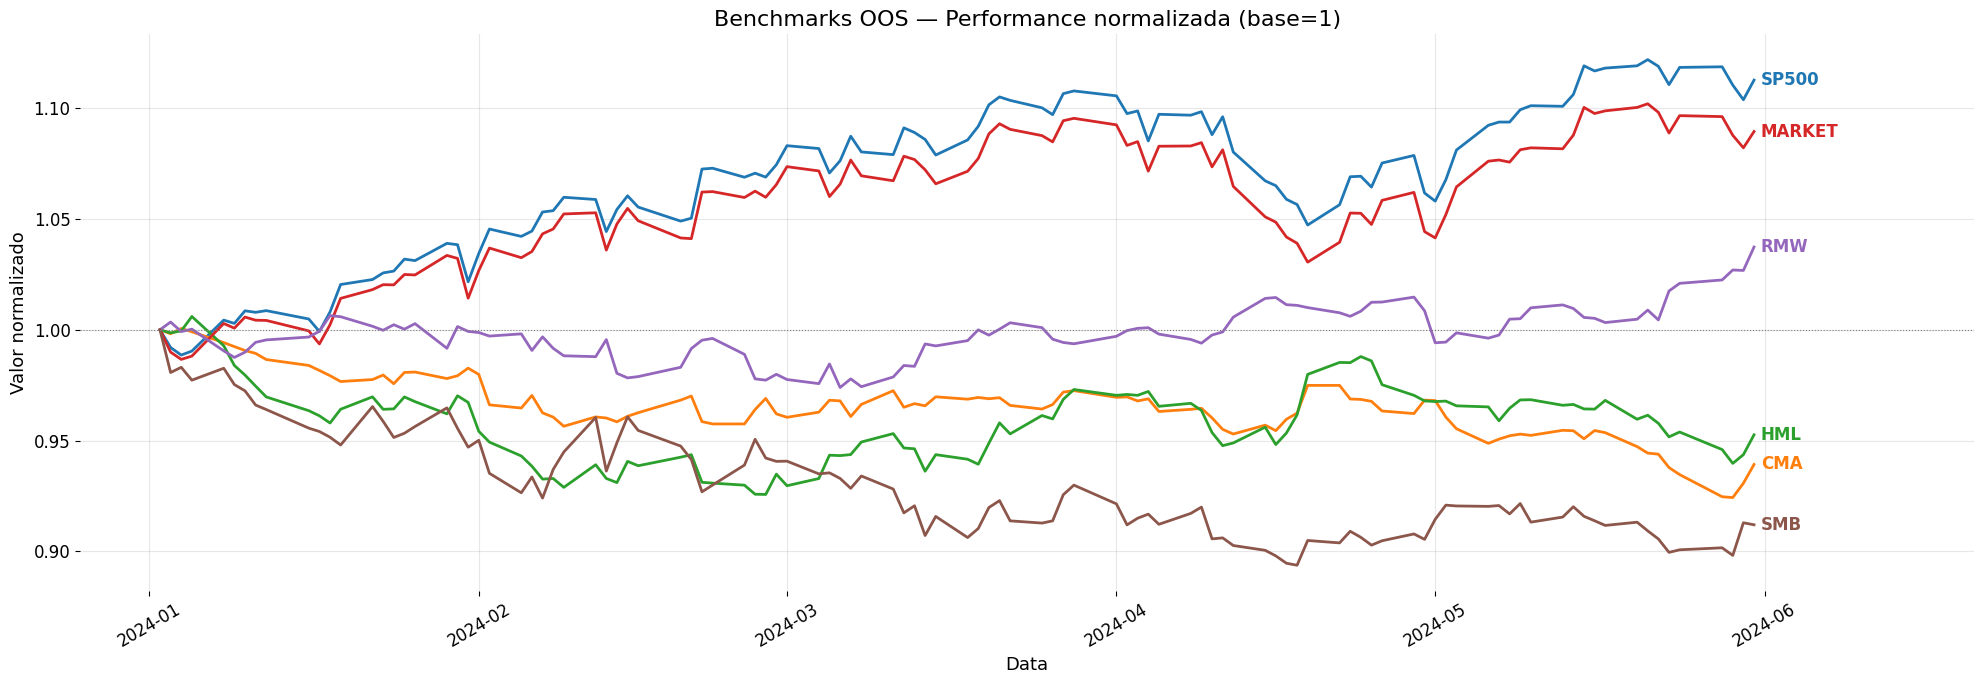

In [4]:
# Combined overview: all benchmarks normalised together
fig, ax = plt.subplots(figsize=(20, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, (b, d) in enumerate(bench_data.items()):
    norm  = d['norm']
    color = colors[i % len(colors)]
    ax.plot(norm.index, norm.values, linewidth=2.0, color=color)
    ax.annotate(b, xy=(norm.index[-1], norm.iloc[-1]),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=12, color=color, fontweight='bold')

ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.08)
ax.set_title('Benchmarks OOS — Performance normalizada (base=1)', fontsize=16)
ax.set_xlabel('Data', fontsize=13)
ax.set_ylabel('Valor normalizado', fontsize=13)
ax.tick_params(axis='x', rotation=30)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.savefig(SCMSSD_DIR / 'benchmarks_overview.png', dpi=150, bbox_inches='tight')
plt.show()

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/market_context_sp500.png


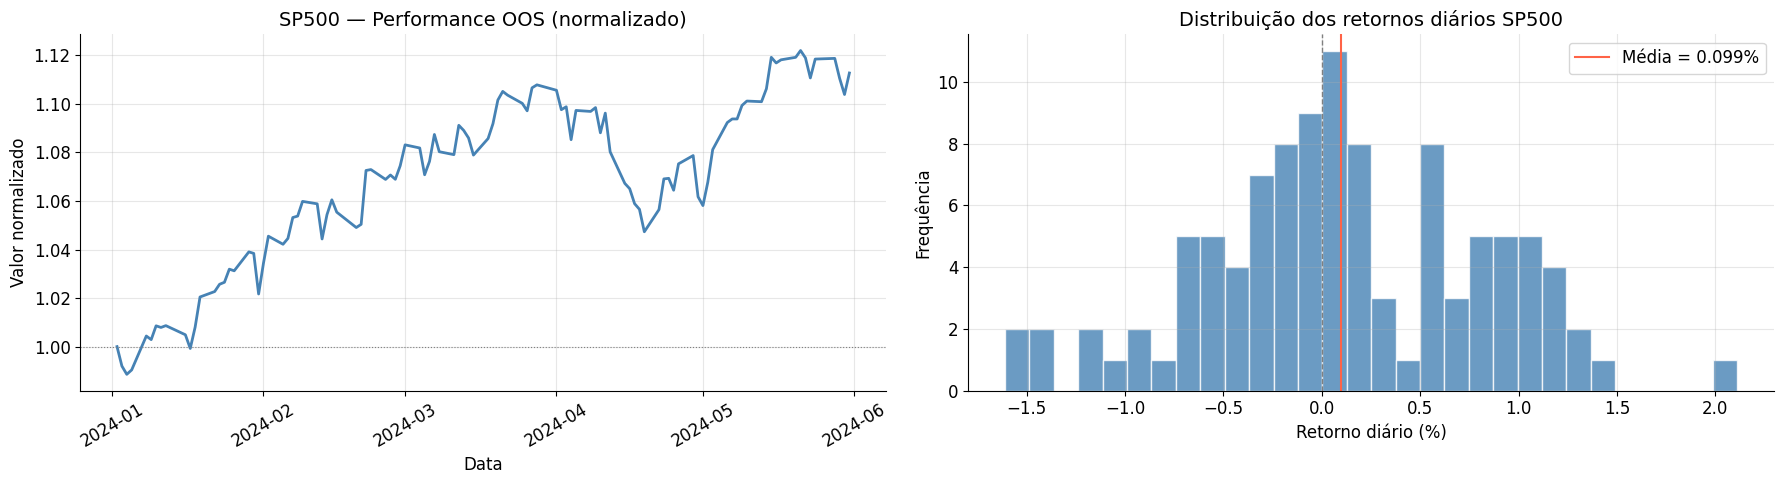

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/market_context_cma.png


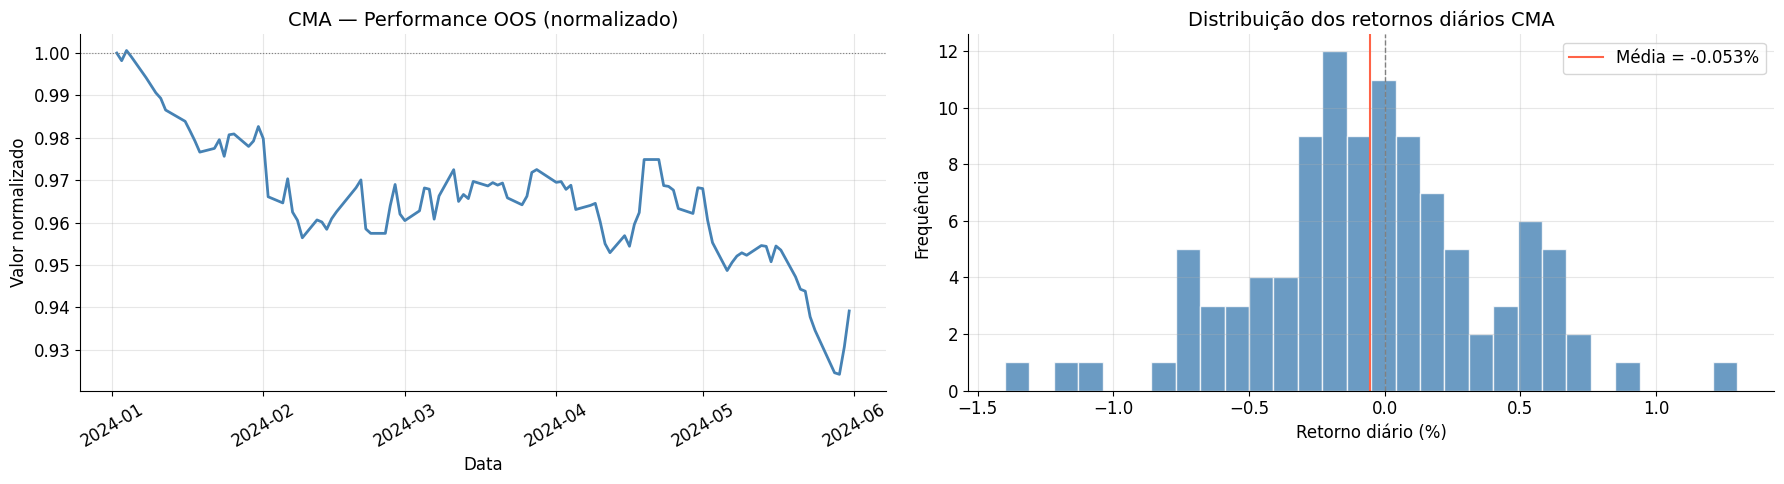

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/market_context_hml.png


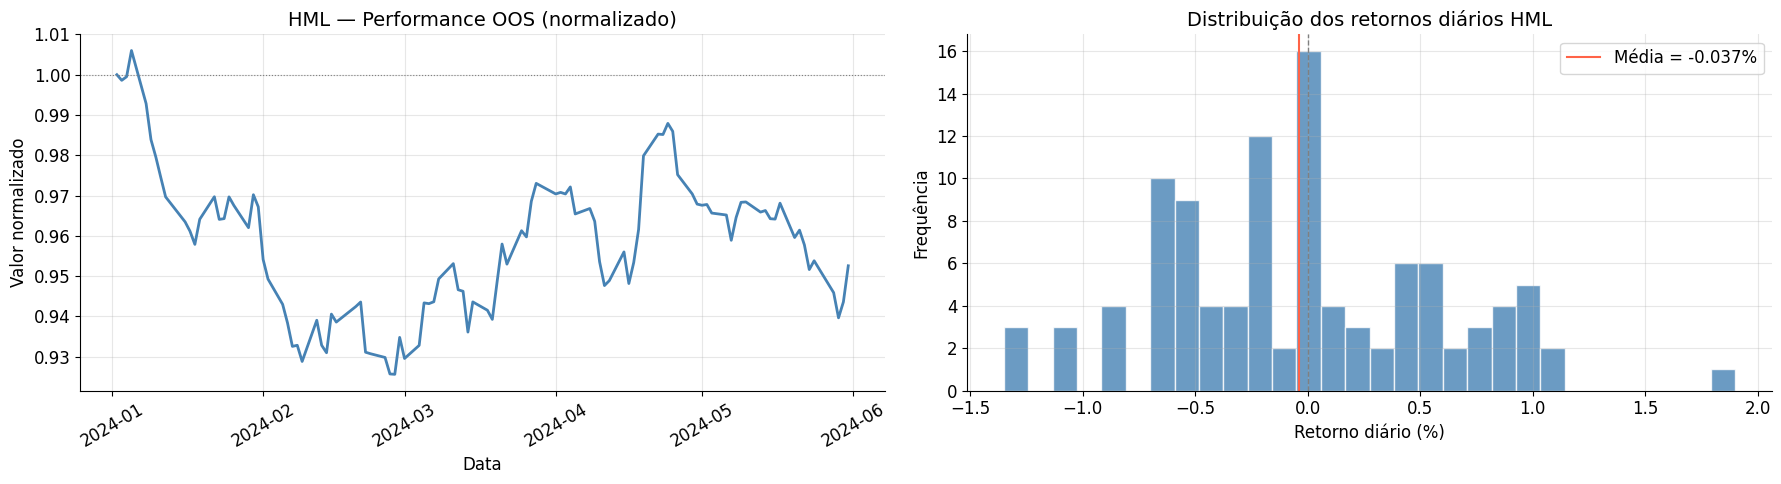

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/market_context_market.png


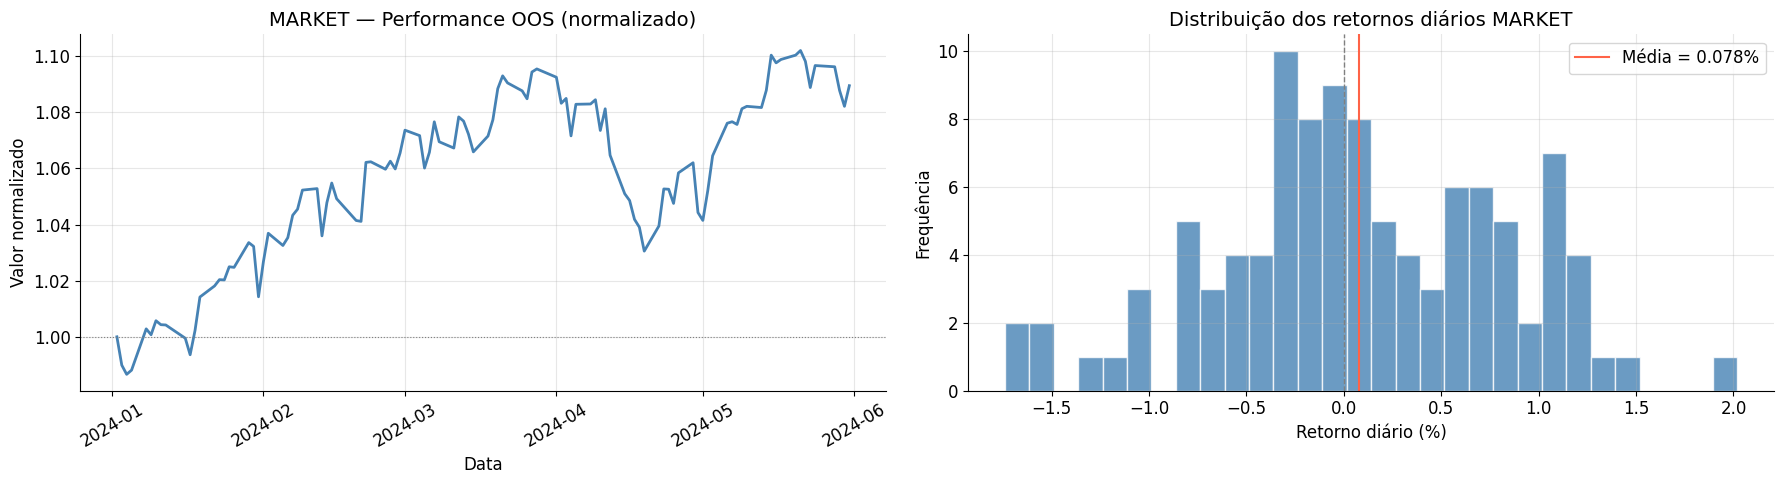

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/market_context_rmw.png


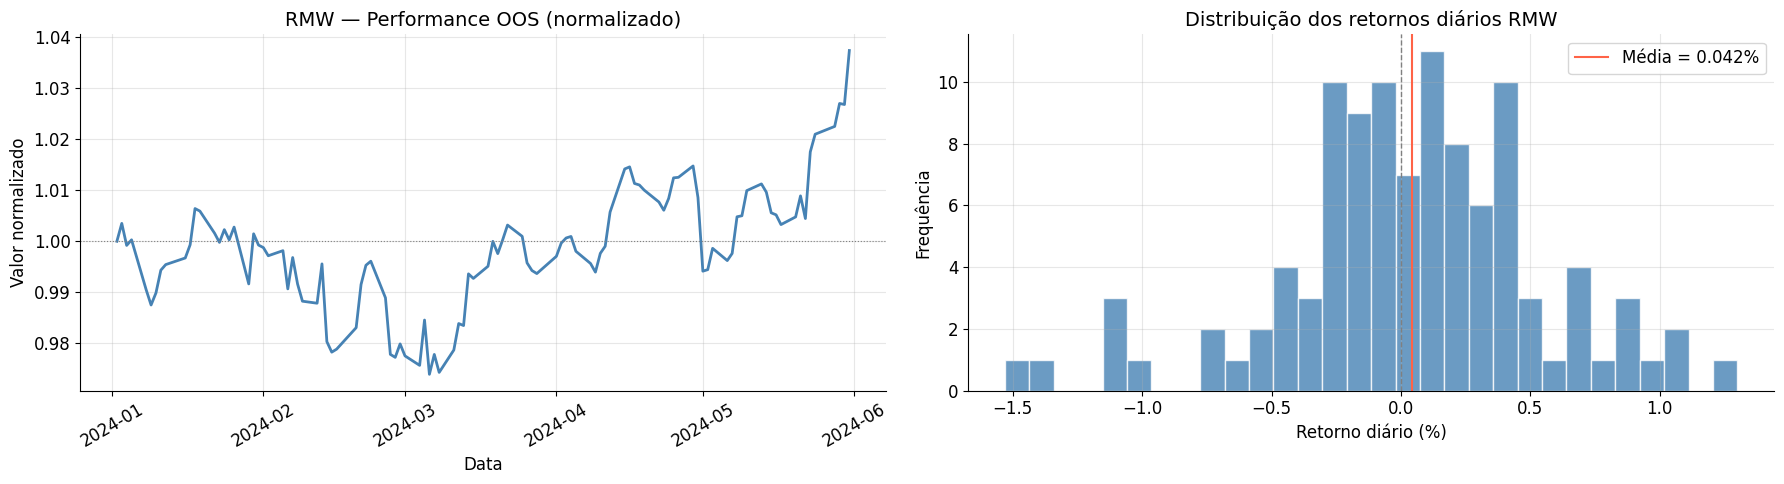

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/market_context_smb.png


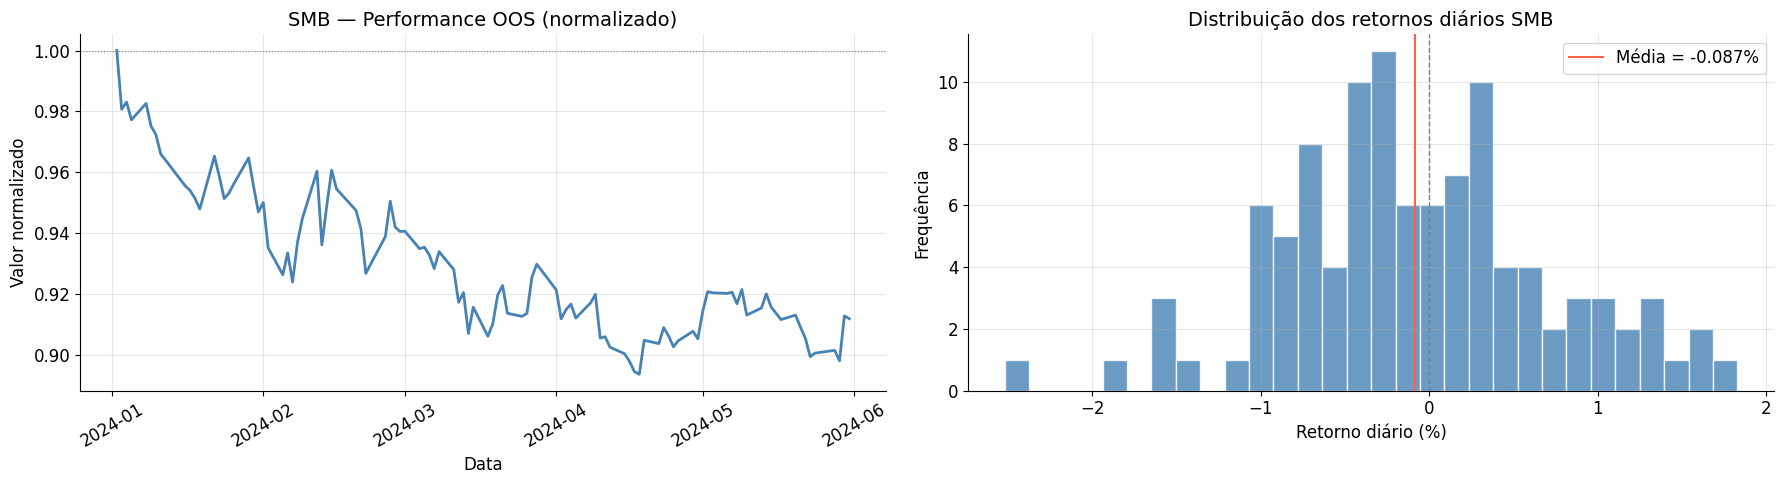

In [5]:
# Individual market context per benchmark (performance + return distribution)
for bench, d in bench_data.items():
    plot_market_context(
        d['norm'], d['ret'],
        benchmark_name=bench,
        save_path=SCMSSD_DIR / f'market_context_{bench.lower()}.png',
    )

---
## 4. Métricas de desempenho OOS

### 4a. Todos os modelos vs SP500 (benchmark primário)

In [6]:
sp500_norm = bench_data['SP500']['norm']

rows = {'SP500': compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)}
for name, series in models.items():
    rows[name] = compute_metrics(series, benchmark=sp500_norm, rf_annual=RISK_FREE)

metrics_df = pd.DataFrame(rows).T
display(
    metrics_df.style
    .background_gradient(cmap='RdYlGn',
                         subset=['Final value', 'CAGR (%)', 'Sharpe Ratio', 'Sortino Ratio'])
    .background_gradient(cmap='RdYlGn_r',
                         subset=['Volatility (%)', 'Daily CVaR 5% (%)', 'Max Drawdown (%)'])
    .format(precision=4, na_rep='--')
)

,Final value,CAGR (%),Volatility (%),Daily CVaR 5% (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Portfolio beta
SP500,1.1127,29.5400,11.3400,1.4070,1.9096,3.5279,-5.4600,1.0000
SSD SP500,1.4911,163.2900,18.2900,1.9300,5.1260,15.2550,-6.9300,1.0043
SSD CMA,1.1270,33.5900,7.9300,0.8550,3.0776,6.6670,-4.3300,0.4519
SSD HML,1.3917,122.7500,15.3300,1.6120,4.9903,13.6981,-6.5700,0.8740
SSD MARKET,1.5458,187.2900,19.8100,2.0450,5.1909,16.2442,-7.0600,1.0749
SSD RMW,1.2423,69.1700,11.0000,1.2260,4.3970,9.7383,-5.0600,0.6417
SSD SMB,1.4568,148.8400,18.4200,2.0720,4.7853,13.1262,-8.1100,0.9653


### 4b. Cada modelo vs seu próprio benchmark de otimização

In [7]:
rows_own = {}
for bench, series in portfolios.items():
    bench_norm = bench_data[bench]['norm']
    rows_own[bench]           = compute_metrics(bench_norm, benchmark=bench_norm, rf_annual=RISK_FREE)
    rows_own[f'SSD {bench}'] = compute_metrics(series,     benchmark=bench_norm, rf_annual=RISK_FREE)

display(
    pd.DataFrame(rows_own).T.style
    .background_gradient(cmap='RdYlGn', subset=['Final value', 'CAGR (%)', 'Sharpe Ratio'])
    .background_gradient(cmap='RdYlGn_r', subset=['Volatility (%)', 'Max Drawdown (%)'])
    .format(precision=4, na_rep='--')
)

,Final value,CAGR (%),Volatility (%),Daily CVaR 5% (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Portfolio beta
SP500,1.1127,29.5400,11.3400,1.4070,1.9096,3.5279,-5.4600,1.0000
SSD SP500,1.4911,163.2900,18.2900,1.9300,5.1260,15.2550,-6.9300,1.0043
CMA,0.9392,-14.1000,7.0900,1.0020,-2.7965,-3.9771,-7.6300,1.0000
SSD CMA,1.1270,33.5900,7.9300,0.8550,3.0776,6.6670,-4.3300,-0.0655
HML,0.9526,-11.1100,9.8200,1.1970,-1.6465,-2.9185,-7.9900,1.0000
SSD HML,1.3917,122.7500,15.3300,1.6120,4.9903,13.6981,-6.5700,-0.2430
MARKET,1.0895,23.0900,11.7700,1.5100,1.4095,2.4264,-5.9300,1.0000
SSD MARKET,1.5458,187.2900,19.8100,2.0450,5.1909,16.2442,-7.0600,1.0261
RMW,1.0374,9.3000,7.9900,1.2080,0.5418,0.7293,-3.2300,1.0000
SSD RMW,1.2423,69.1700,11.0000,1.2260,4.3970,9.7383,-5.0600,0.0319


---
## 5. Comparação de performance OOS — todos os modelos e benchmarks

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/performance_comparison_combined.png


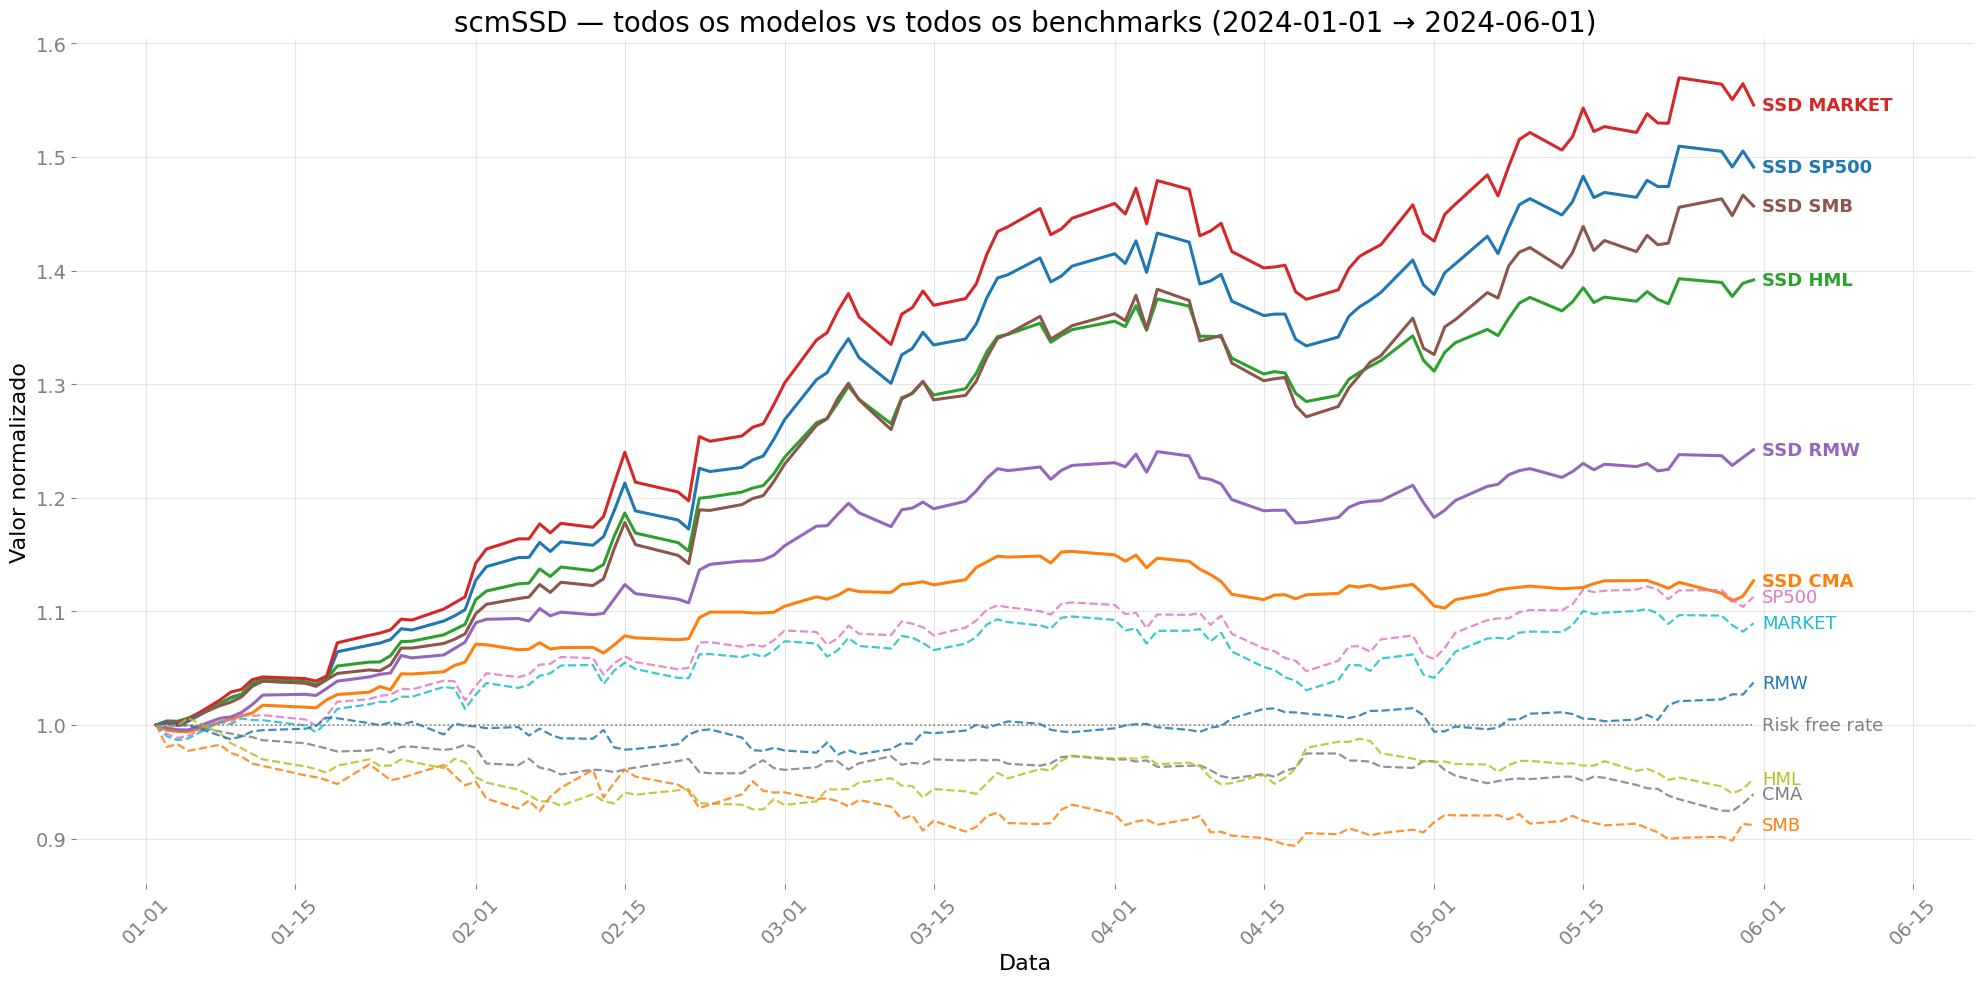

In [8]:
combined = pd.DataFrame(index=idx)
for b, s in portfolios.items():
    combined[f'SSD {b}'] = s
for b, d in bench_data.items():
    combined[b] = d['norm']
combined['Risk free rate'] = 1.0

plot_portfolio_comparison(
    combined,
    force_background=True,
    benchmark_cols=AVAILABLE_BENCHMARKS,
    title=f'scmSSD — todos os modelos vs todos os benchmarks ({OOS_START} → {OOS_END})',
    save_path=SCMSSD_DIR / 'performance_comparison_combined.png',
)

---
## 6. Curvas de dominância SSD

### 6a. Dominância home — cada modelo vs seu benchmark de otimização

`SSD_B` domina `B` ⟺ min(SSD) ≥ 0 em todos os cenários OOS.

Modelo          Benchmark     min(SSD)    min(FSD)  Status
------------------------------------------------------------------
  SSD SP500       SP500        -0.074537   -0.009803  ✗ VIOLA
  SSD CMA         CMA          +0.004033   -0.000465  ✓ DOMINA
  SSD HML         HML          -0.046201   -0.005842  ✗ VIOLA
  SSD MARKET      MARKET       -0.078394   -0.010448  ✗ VIOLA
  SSD RMW         RMW          -0.023199   -0.002536  ✗ VIOLA
  SSD SMB         SMB          -0.042309   -0.004962  ✗ VIOLA
[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/ssd_dominance_home.png


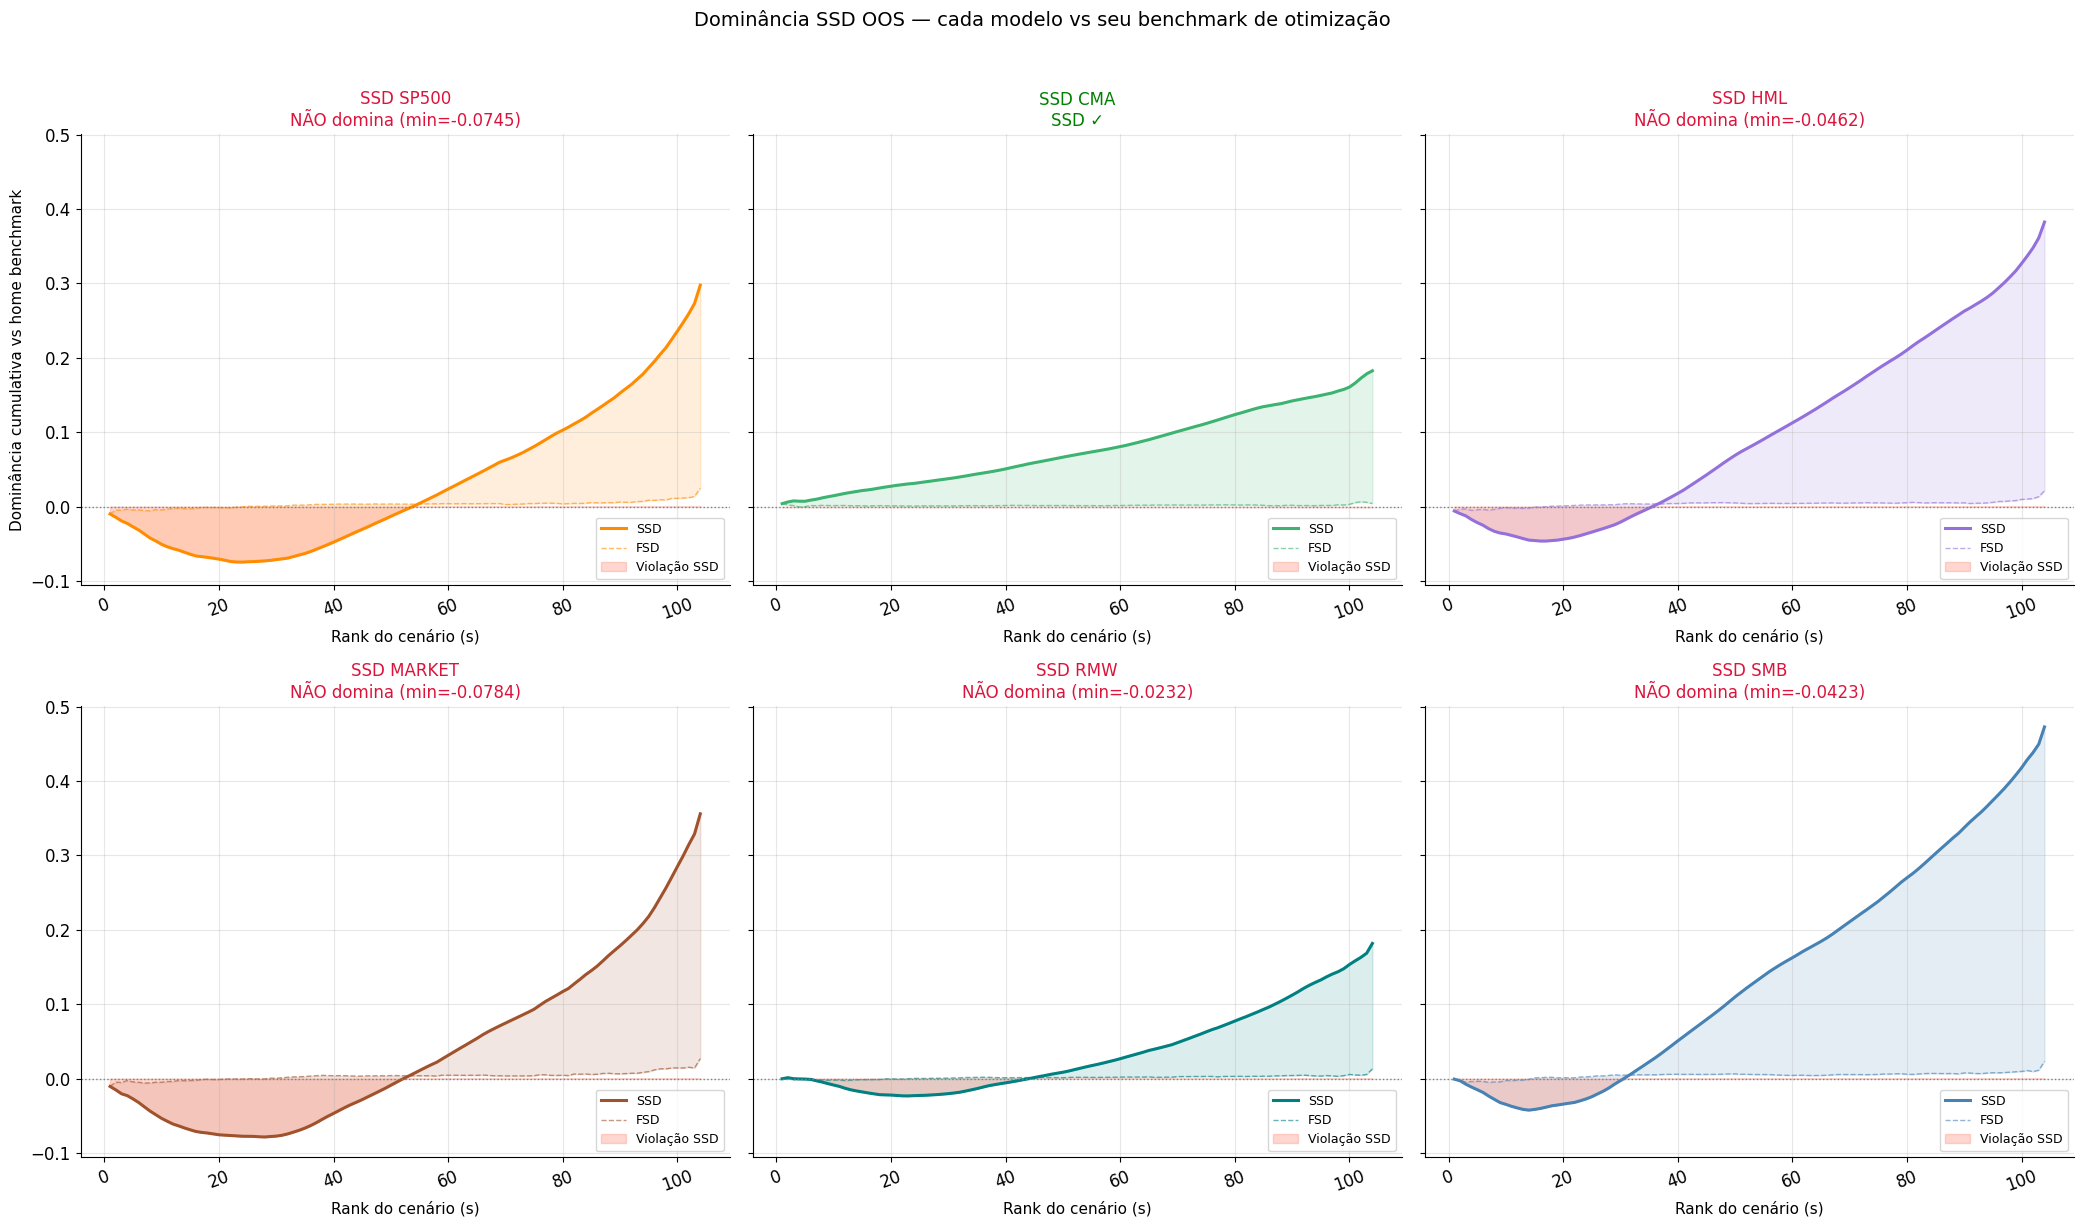

In [9]:
home_dominance = {}  # {bench: (s, fsd, ssd)}

print(f'{"Modelo":<14}  {"Benchmark":<10}  {"min(SSD)":>10}  {"min(FSD)":>10}  Status')
print('-' * 66)
for bench, series in portfolios.items():
    port_ret  = series.pct_change().dropna()
    bench_ret = bench_data[bench]['ret']
    common    = port_ret.index.intersection(bench_ret.index)
    s, fsd, ssd = compute_ssd_dominance(port_ret.loc[common].values, bench_ret.loc[common].values)
    home_dominance[bench] = (s, fsd, ssd)
    tag = '✓ DOMINA' if ssd.min() >= 0 else f'✗ VIOLA'
    print(f'  SSD {bench:<10}  {bench:<10}  {ssd.min():+10.6f}  {fsd.min():+10.6f}  {tag}')

dom_plot = {f'SSD {b}': v for b, v in home_dominance.items()}
plot_dominance_panels(
    dom_plot, n_cols=3,
    benchmark_name='home benchmark',
    title='Dominância SSD OOS — cada modelo vs seu benchmark de otimização',
    save_path=SCMSSD_DIR / 'ssd_dominance_home.png',
)

### 6b. Matriz de dominância cruzada — todos os modelos × todos os benchmarks

Cada célula mostra `min(SSD)` para o par (modelo, benchmark). Verde = domina (≥ 0), vermelho = viola.

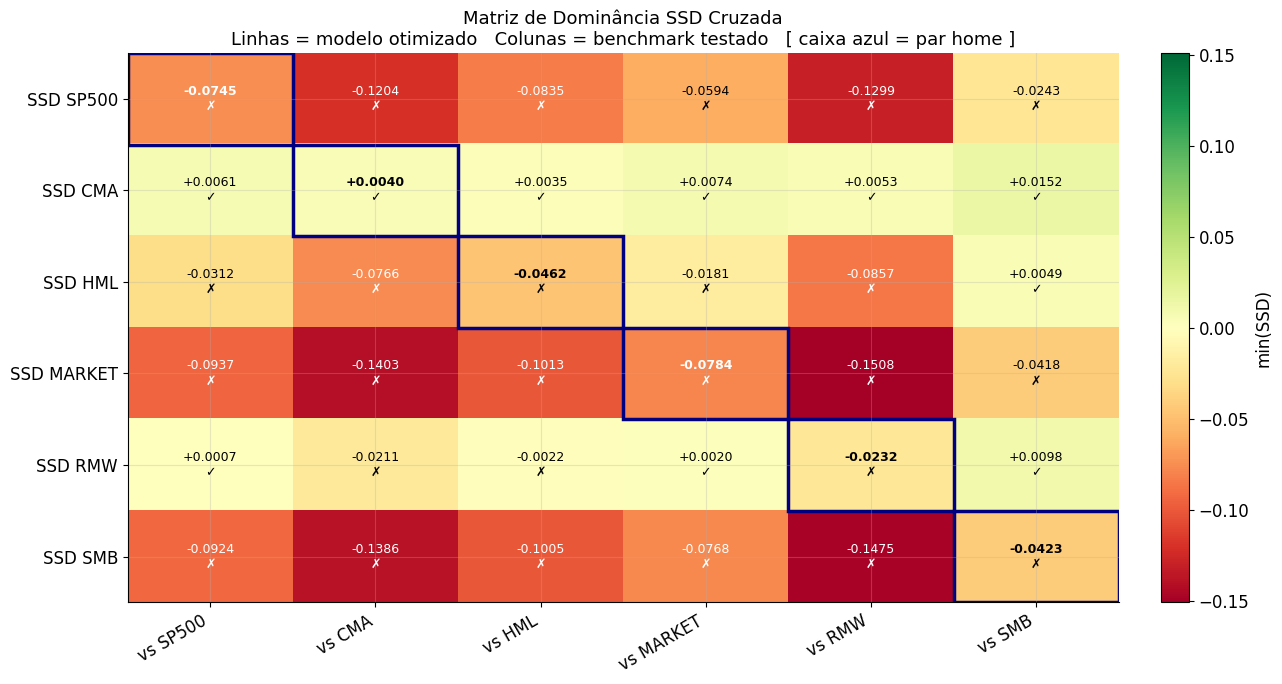

,vs SP500,vs CMA,vs HML,vs MARKET,vs RMW,vs SMB
SSD SP500,-0.07454,-0.12039,-0.08346,-0.05944,-0.12986,-0.02433
SSD CMA,+0.00614,+0.00403,+0.00353,+0.00743,+0.00533,+0.01523
SSD HML,-0.03124,-0.07659,-0.04620,-0.01805,-0.08565,+0.00487
SSD MARKET,-0.09370,-0.14029,-0.10132,-0.07839,-0.15085,-0.04182
SSD RMW,+0.00066,-0.02107,-0.00220,+0.00195,-0.02320,+0.00975
SSD SMB,-0.09241,-0.13859,-0.10054,-0.07679,-0.14753,-0.04231


In [10]:
# Compute all 6×6 pairs
cross_dom = {}  # {(model_bench, vs_bench): (s, fsd, ssd)}

for mb, port_series in portfolios.items():
    port_ret = port_series.pct_change().dropna()
    for vb, bdata in bench_data.items():
        common = port_ret.index.intersection(bdata['ret'].index)
        if len(common) < 2:
            continue
        s, fsd, ssd = compute_ssd_dominance(
            port_ret.loc[common].values, bdata['ret'].loc[common].values
        )
        cross_dom[(mb, vb)] = (s, fsd, ssd)

model_keys = [b for b in AVAILABLE_BENCHMARKS if b in portfolios]
vs_keys    = list(bench_data.keys())

matrix = np.full((len(model_keys), len(vs_keys)), np.nan)
for i, mb in enumerate(model_keys):
    for j, vb in enumerate(vs_keys):
        if (mb, vb) in cross_dom:
            _, _, ssd = cross_dom[(mb, vb)]
            matrix[i, j] = ssd.min()

# Heatmap
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

vmax = max(abs(np.nanmin(matrix)), abs(np.nanmax(matrix)))
im   = ax.imshow(matrix, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('min(SSD)', fontsize=12)

ax.set_xticks(range(len(vs_keys)))
ax.set_xticklabels([f'vs {b}' for b in vs_keys], rotation=30, ha='right', fontsize=12)
ax.set_yticks(range(len(model_keys)))
ax.set_yticklabels([f'SSD {b}' for b in model_keys], fontsize=12)

# Draw diagonal box to highlight home pairs
for i, mb in enumerate(model_keys):
    for j, vb in enumerate(vs_keys):
        val = matrix[i, j]
        if np.isnan(val):
            continue
        txt_color = 'white' if abs(val) > vmax * 0.45 else 'black'
        mark      = '✓' if val >= 0 else '✗'
        is_home   = (mb == vb)
        ax.text(j, i, f'{val:+.4f}\n{mark}',
                ha='center', va='center', fontsize=9,
                color=txt_color, fontweight='bold' if is_home else 'normal')
        if is_home:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                  linewidth=2.5, edgecolor='navy', facecolor='none')
            ax.add_patch(rect)

ax.set_title(
    'Matriz de Dominância SSD Cruzada\n'
    'Linhas = modelo otimizado   Colunas = benchmark testado   '
    '[ caixa azul = par home ]',
    fontsize=13
)
plt.tight_layout()
plt.savefig(SCMSSD_DIR / 'ssd_dominance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela
df_mat = pd.DataFrame(matrix,
                      index=[f'SSD {b}' for b in model_keys],
                      columns=[f'vs {b}' for b in vs_keys])
display(df_mat.style
    .background_gradient(cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    .format('{:+.5f}', na_rep='--'))

### 6c. Dominância por benchmark — todos os modelos vs cada benchmark

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/ssd_dominance_vs_sp500.png


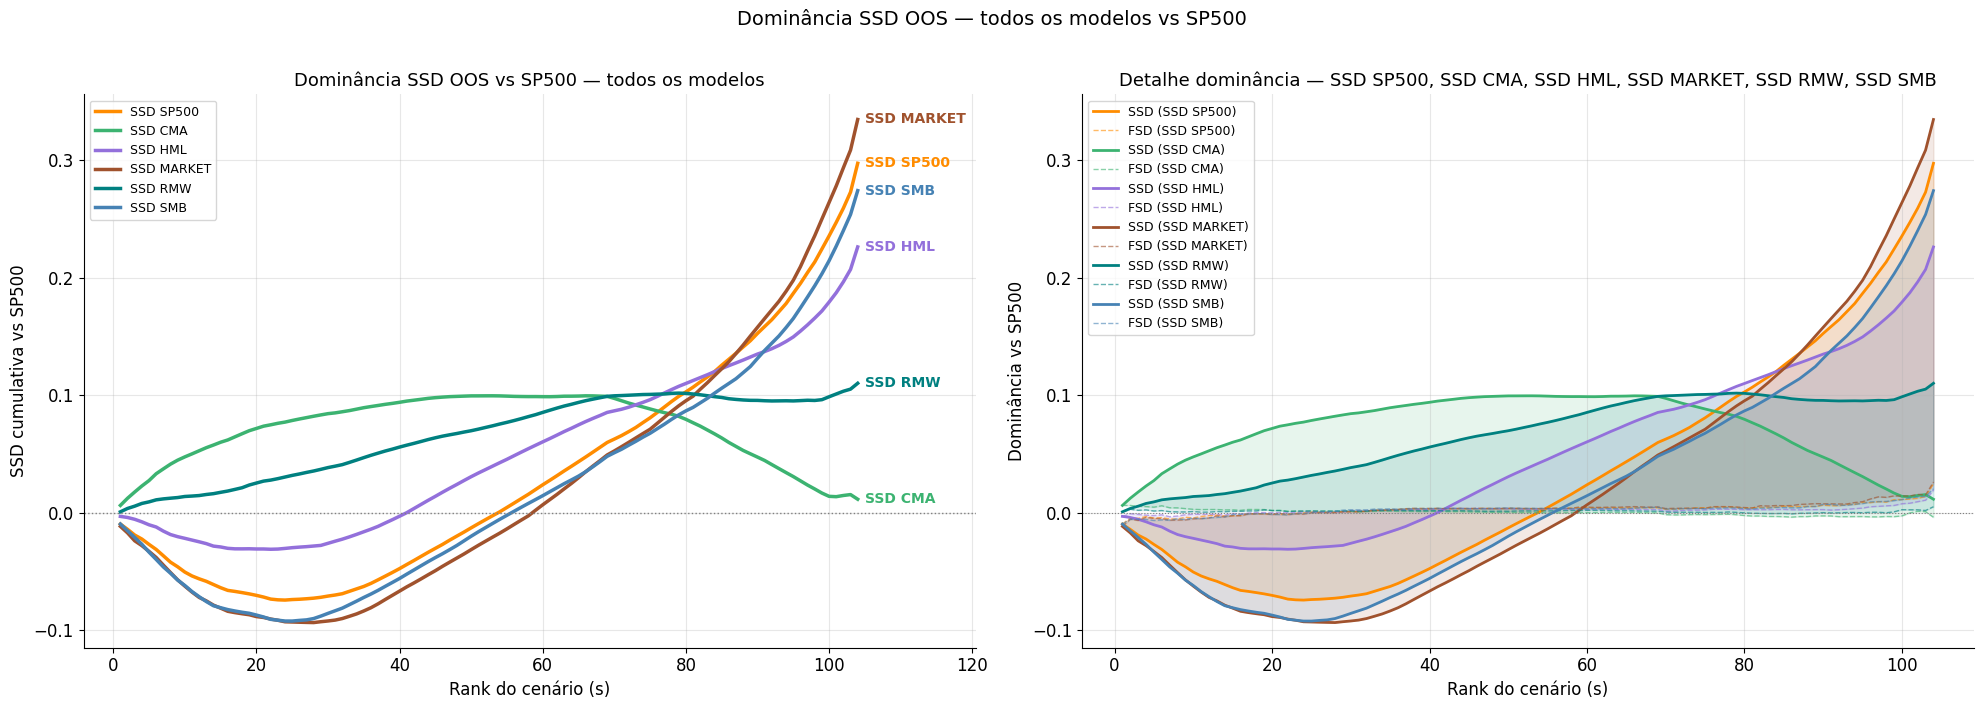

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/ssd_dominance_vs_cma.png


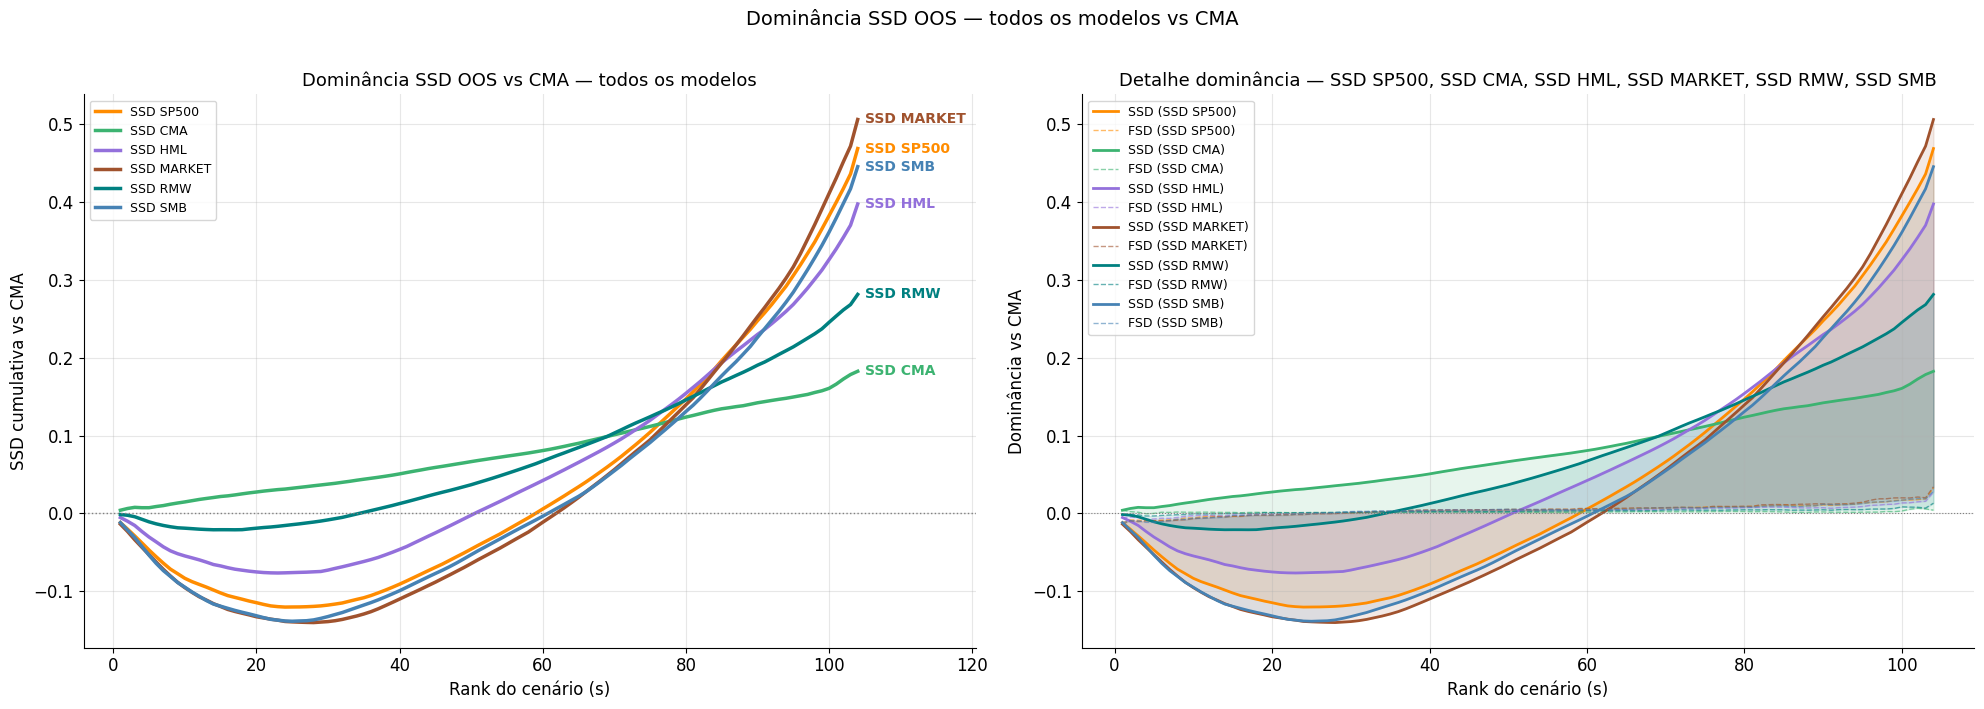

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/ssd_dominance_vs_hml.png


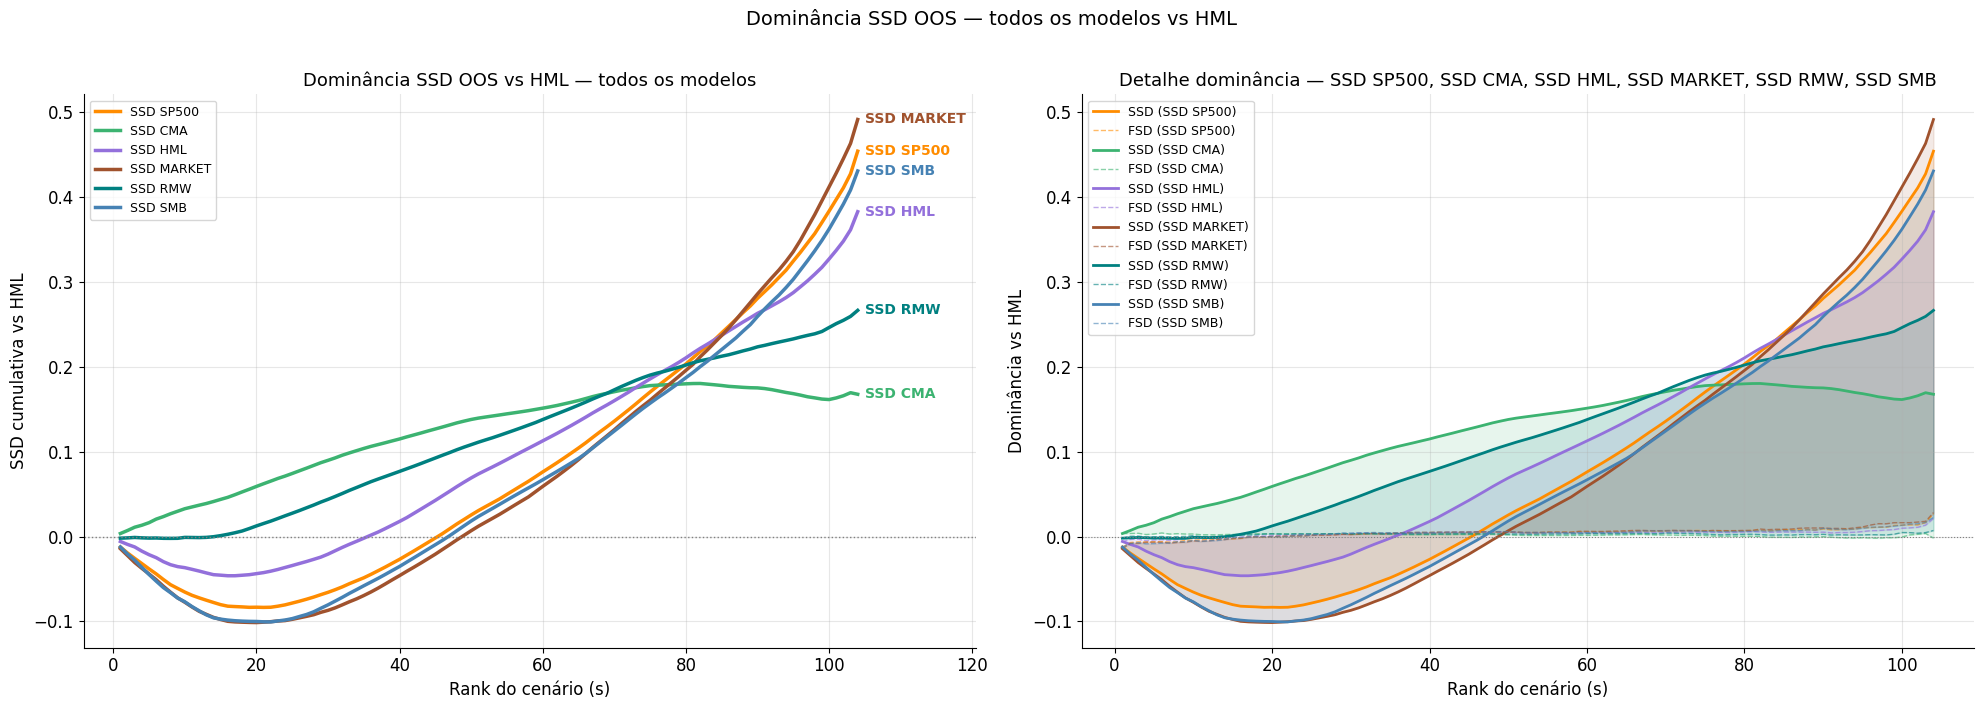

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/ssd_dominance_vs_market.png


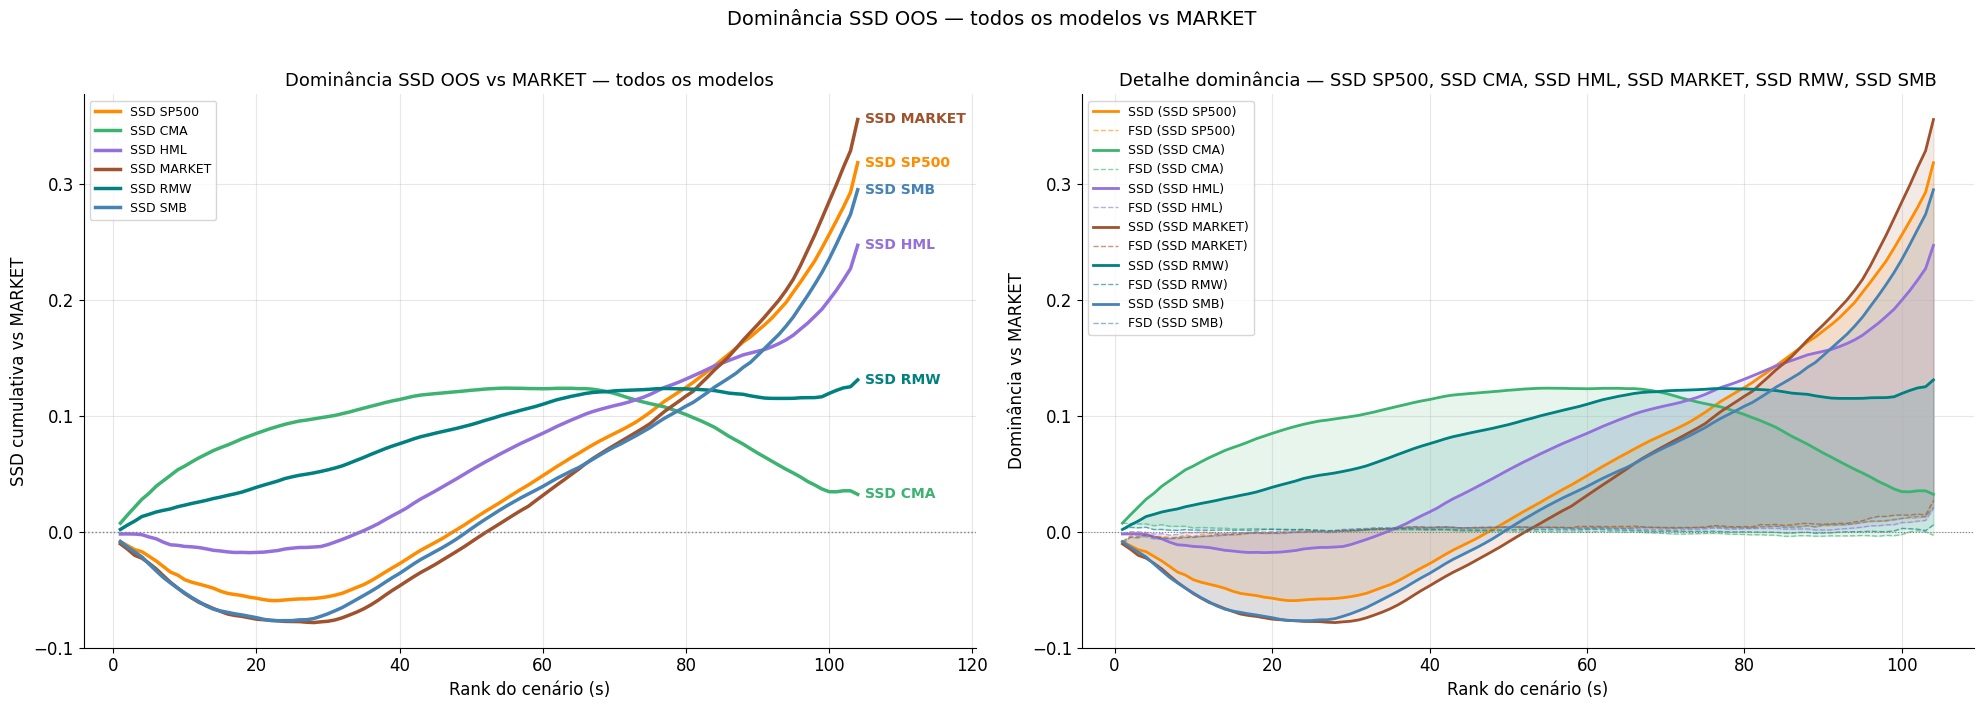

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/ssd_dominance_vs_rmw.png


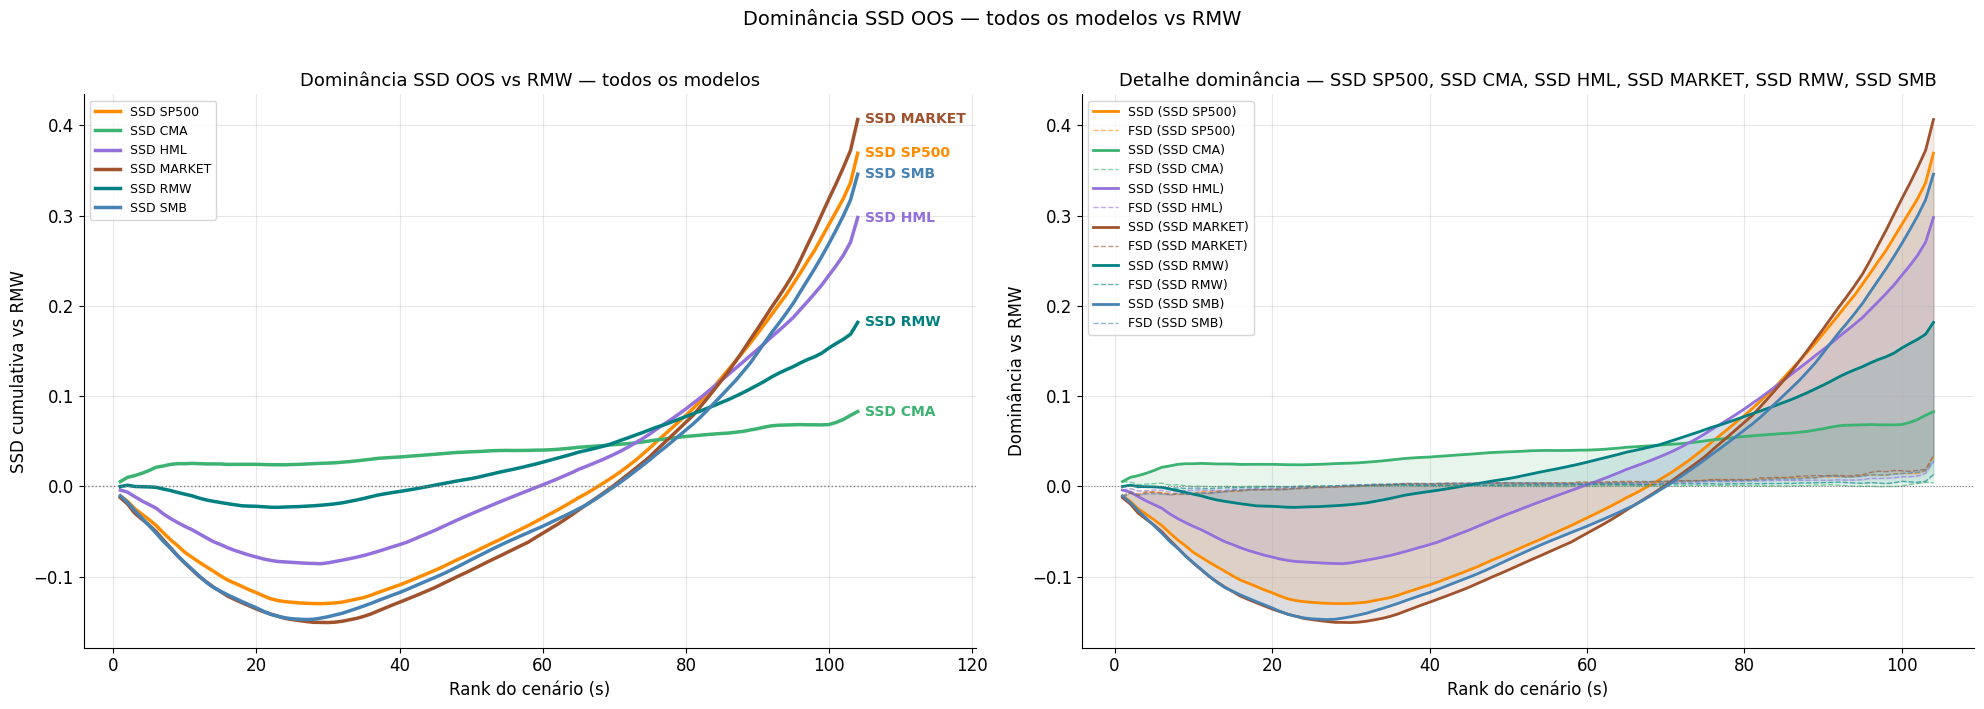

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/ssd_dominance_vs_smb.png


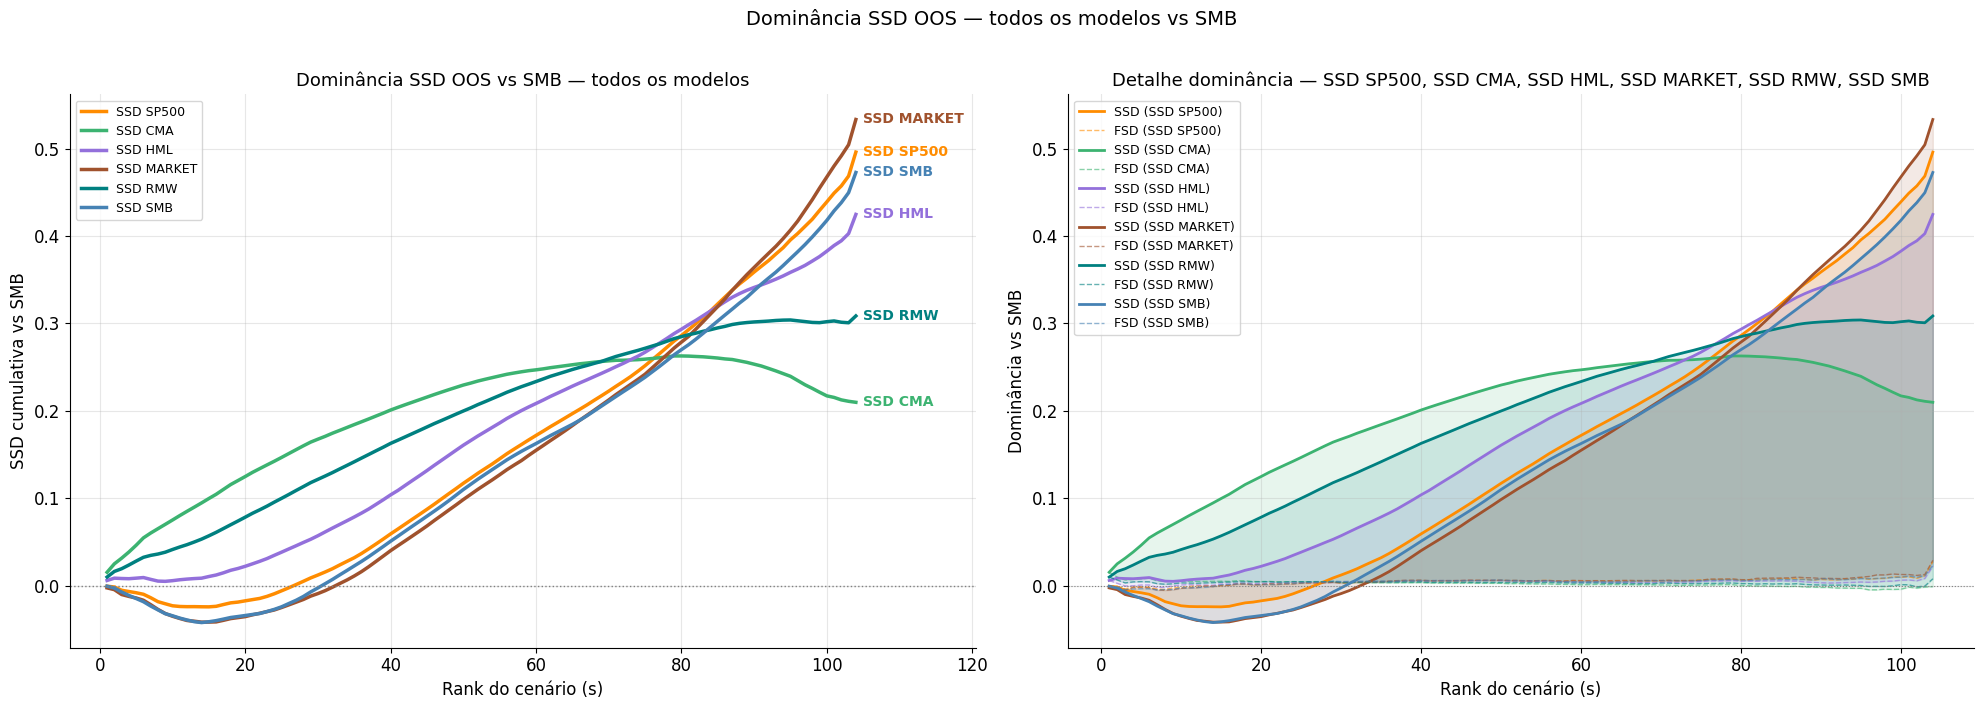

In [11]:
for vb in vs_keys:
    dom_vs = {f'SSD {mb}': cross_dom[(mb, vb)]
              for mb in model_keys if (mb, vb) in cross_dom}
    if not dom_vs:
        continue
    plot_dominance_overview(
        dom_vs,
        benchmark_name=vb,
        title=f'Dominância SSD OOS — todos os modelos vs {vb}',
        save_path=SCMSSD_DIR / f'ssd_dominance_vs_{vb.lower()}.png',
    )

---
## 7. Análise de risco × retorno

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/risk_return_scatter.png


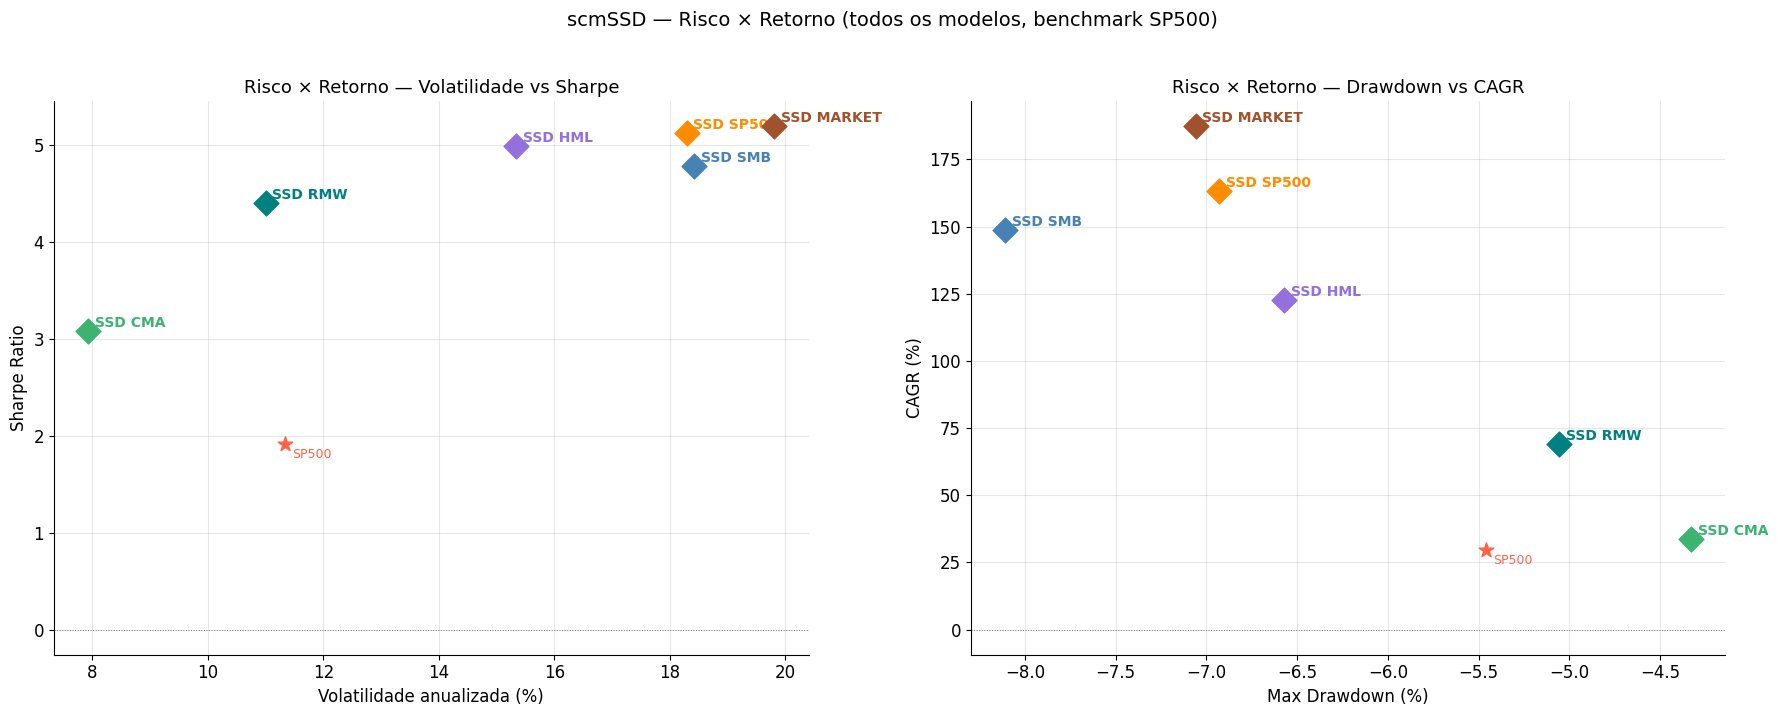

In [12]:
plot_risk_return_scatter(
    models, sp500_norm,
    rf_annual=RISK_FREE,
    title='scmSSD — Risco × Retorno (todos os modelos, benchmark SP500)',
    save_path=SCMSSD_DIR / 'risk_return_scatter.png',
)

---
## 8. Distribuição de retornos e correlação

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/return_distribution.png


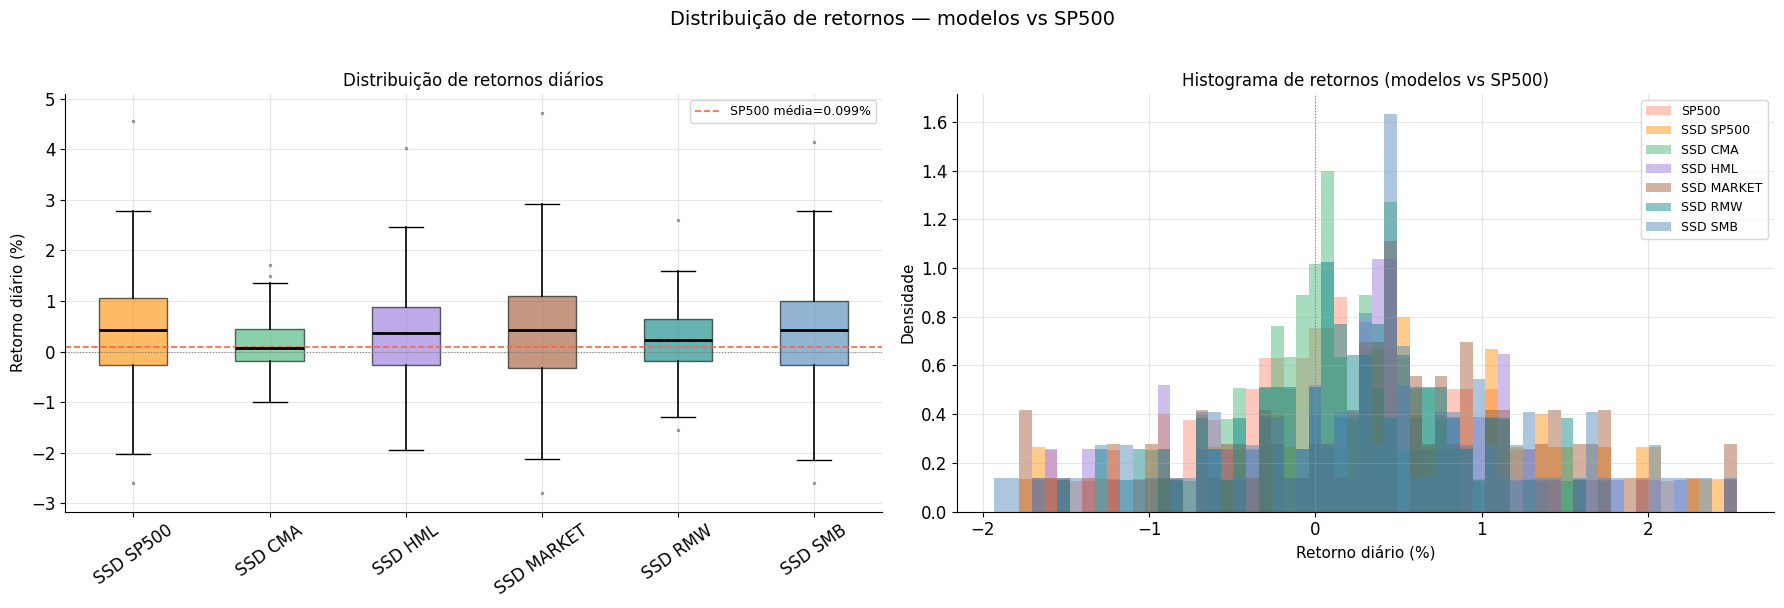

In [13]:
plot_return_distribution(
    models, bench_data['SP500']['ret'],
    highlight_keys=list(models.keys()),
    save_path=SCMSSD_DIR / 'return_distribution.png',
)

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/correlation_matrix.png


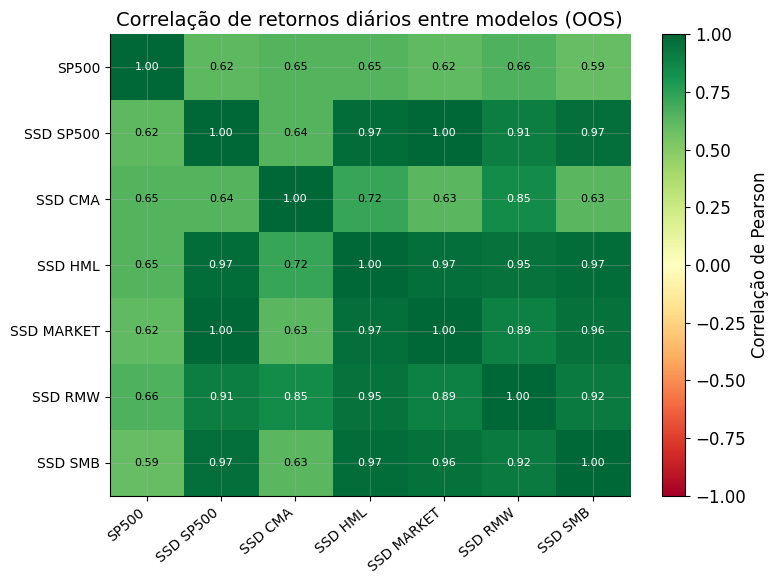

In [14]:
plot_correlation_matrix(
    models, bench_data['SP500']['ret'],
    benchmark_name='SP500',
    save_path=SCMSSD_DIR / 'correlation_matrix.png',
)

---
## 9. Drawdown

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/drawdown.png


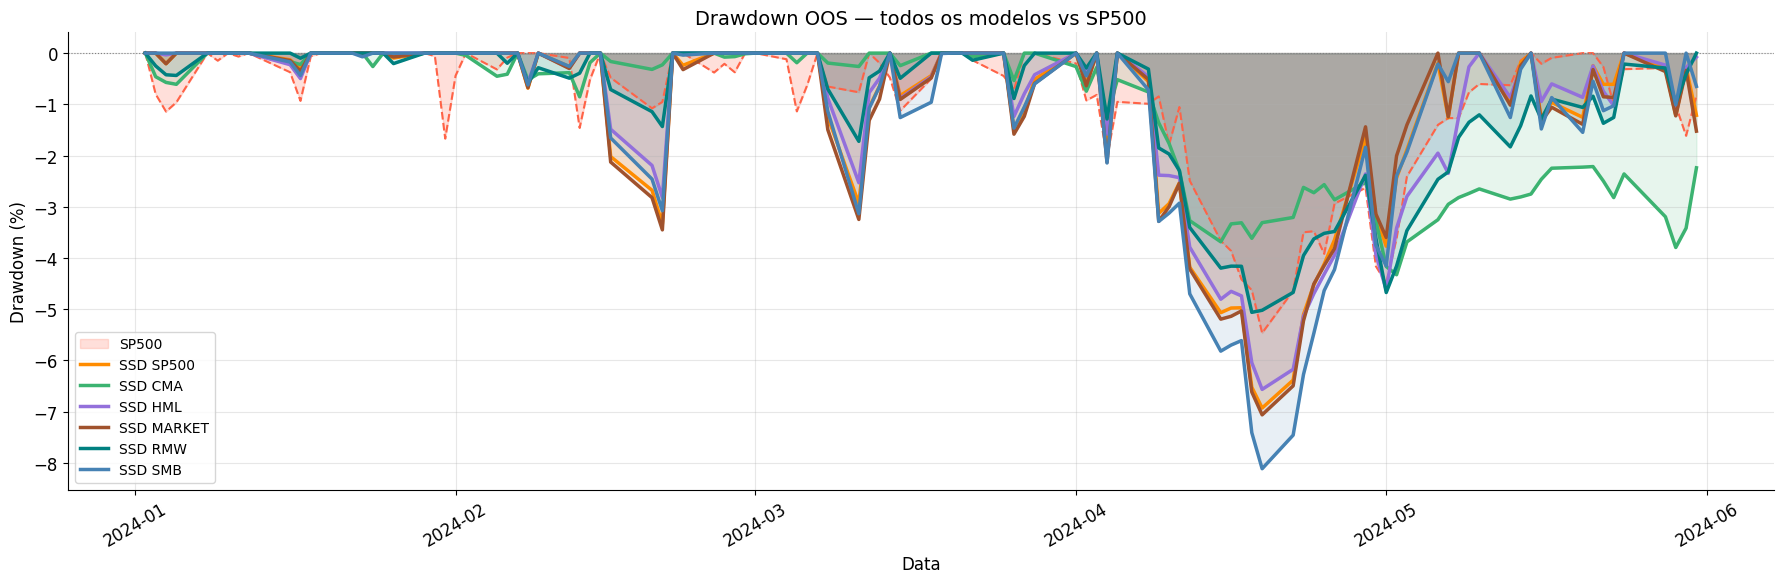

In [15]:
plot_drawdown(
    models, sp500_norm,
    title='Drawdown OOS — todos os modelos vs SP500',
    save_path=SCMSSD_DIR / 'drawdown.png',
)

---
## 10. Retornos em janela deslizante

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/scmssd/rolling_returns.png


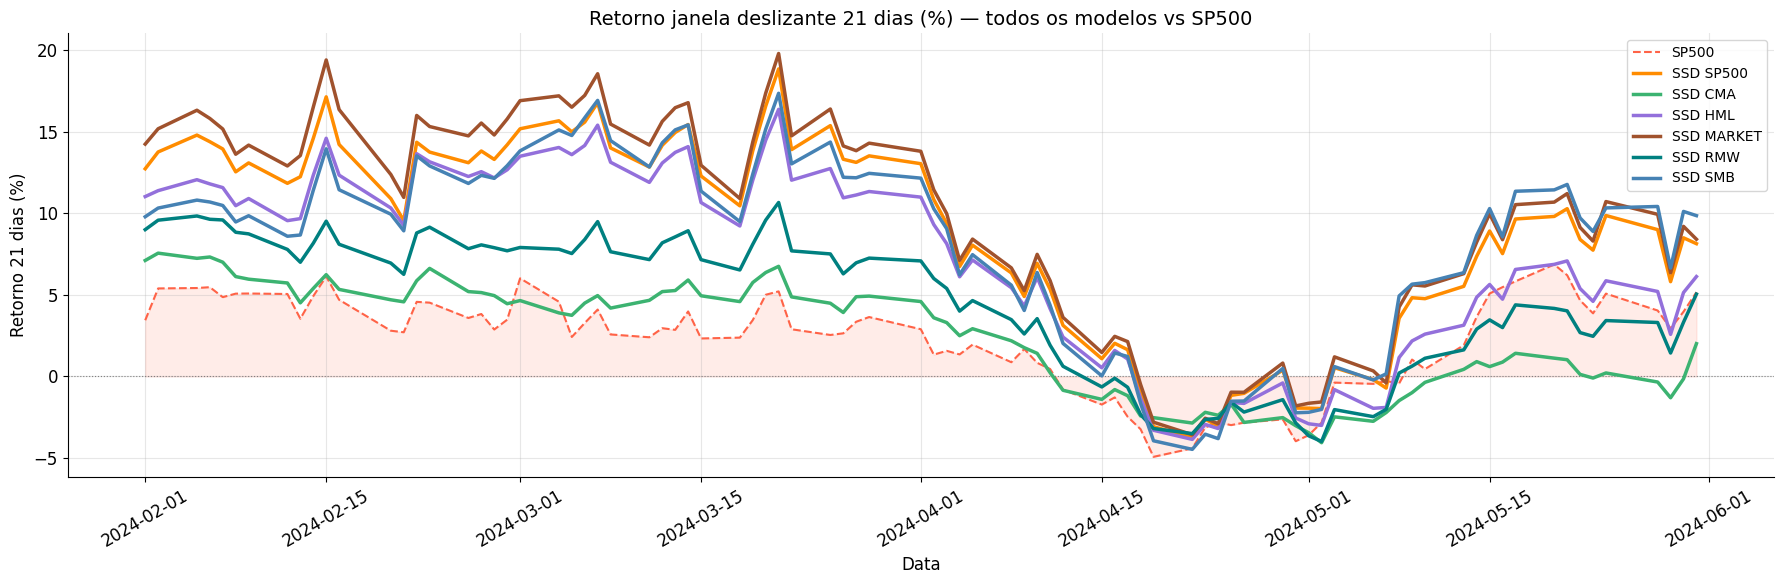

In [16]:
plot_rolling_returns(
    models, sp500_norm,
    window=21,
    title='Retorno janela deslizante 21 dias (%) — todos os modelos vs SP500',
    save_path=SCMSSD_DIR / 'rolling_returns.png',
)

---
## 11. Sumário executivo

In [17]:
print('=' * 92)
print('  scmSSD — SUMÁRIO EXECUTIVO')
print(f'  Período OOS: {OOS_START} → {OOS_END}')
print('=' * 92)

m_sp = compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
print(f"\n  SP500 (referência)  Final={m_sp['Final value']:.4f}  "
      f"CAGR={m_sp['CAGR (%)']:+.2f}%  Sharpe={m_sp['Sharpe Ratio']:.4f}  "
      f"MaxDD={m_sp['Max Drawdown (%)']:.2f}%")

hdr = (f"  {'Modelo':<14}  {'Final':>7}  {'CAGR':>8}  {'Vol':>7}  "
       f"{'CVaR5%':>8}  {'Sharpe':>8}  {'Sortino':>9}  {'MaxDD':>8}  {'Beta':>7}")
print(f'\n{hdr}')
print('  ' + '-' * 88)

for name, series in models.items():
    m        = compute_metrics(series, benchmark=sp500_norm, rf_annual=RISK_FREE)
    beta_str = f"{m['Portfolio beta']:.4f}" if not np.isnan(m['Portfolio beta']) else '--'
    beats    = ' ◄ beats SP500' if m['Sharpe Ratio'] > m_sp['Sharpe Ratio'] else ''
    print(f"  {name:<14}  {m['Final value']:>7.4f}  {m['CAGR (%)']:>+7.2f}%  "
          f"{m['Volatility (%)']:>6.2f}%  {m['Daily CVaR 5% (%)']:>7.3f}%  "
          f"{m['Sharpe Ratio']:>8.4f}  {m['Sortino Ratio']:>9.4f}  "
          f"{m['Max Drawdown (%)']:>+7.2f}%  {beta_str:>7}{beats}")

print('\n' + '=' * 92)

  scmSSD — SUMÁRIO EXECUTIVO
  Período OOS: 2024-01-01 → 2024-06-01

  SP500 (referência)  Final=1.1127  CAGR=+29.54%  Sharpe=1.9096  MaxDD=-5.46%

  Modelo            Final      CAGR      Vol    CVaR5%    Sharpe    Sortino     MaxDD     Beta
  ----------------------------------------------------------------------------------------
  SSD SP500        1.4911  +163.29%   18.29%    1.930%    5.1260    15.2550    -6.93%   1.0043 ◄ beats SP500
  SSD CMA          1.1270   +33.59%    7.93%    0.855%    3.0776     6.6670    -4.33%   0.4519 ◄ beats SP500
  SSD HML          1.3917  +122.75%   15.33%    1.612%    4.9903    13.6981    -6.57%   0.8740 ◄ beats SP500
  SSD MARKET       1.5458  +187.29%   19.81%    2.045%    5.1909    16.2442    -7.06%   1.0749 ◄ beats SP500
  SSD RMW          1.2423   +69.17%   11.00%    1.226%    4.3970     9.7383    -5.06%   0.6417 ◄ beats SP500
  SSD SMB          1.4568  +148.84%   18.42%    2.072%    4.7853    13.1262    -8.11%   0.9653 ◄ beats SP500



In [18]:
print('\n' + '=' * 68)
print('  DOMINÂNCIA SSD — MATRIZ CRUZADA (RESUMO)')
print('=' * 68)
print(f'  {"Modelo":<14}  {"Benchmark":<10}  {"min(SSD)":>10}  Status    Home?')
print('  ' + '-' * 58)
for i, mb in enumerate(model_keys):
    for j, vb in enumerate(vs_keys):
        val  = matrix[i, j]
        if np.isnan(val):
            continue
        tag  = '✓ DOMINA' if val >= 0 else '✗ VIOLA '
        home = ' ← home' if mb == vb else ''
        print(f'  SSD {mb:<10}  {vb:<10}  {val:+10.6f}  {tag}{home}')
print('=' * 68)


  DOMINÂNCIA SSD — MATRIZ CRUZADA (RESUMO)
  Modelo          Benchmark     min(SSD)  Status    Home?
  ----------------------------------------------------------
  SSD SP500       SP500        -0.074537  ✗ VIOLA  ← home
  SSD SP500       CMA          -0.120388  ✗ VIOLA 
  SSD SP500       HML          -0.083458  ✗ VIOLA 
  SSD SP500       MARKET       -0.059439  ✗ VIOLA 
  SSD SP500       RMW          -0.129861  ✗ VIOLA 
  SSD SP500       SMB          -0.024329  ✗ VIOLA 
  SSD CMA         SP500        +0.006139  ✓ DOMINA
  SSD CMA         CMA          +0.004033  ✓ DOMINA ← home
  SSD CMA         HML          +0.003533  ✓ DOMINA
  SSD CMA         MARKET       +0.007433  ✓ DOMINA
  SSD CMA         RMW          +0.005333  ✓ DOMINA
  SSD CMA         SMB          +0.015233  ✓ DOMINA
  SSD HML         SP500        -0.031236  ✗ VIOLA 
  SSD HML         CMA          -0.076590  ✗ VIOLA 
  SSD HML         HML          -0.046201  ✗ VIOLA  ← home
  SSD HML         MARKET       -0.018050  ✗ VIOLA 
